<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week11_2_%EC%B5%9C%EC%A0%81%ED%99%94%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

딥러닝 파이토치
p461-504

8과 성능 최적화

##8.3 하이퍼파라미터를 이용한 성능최적화

- 방법 : 배치정규화, 드롭아웃, 조기종료


**8.3.1 배치 정규화를 이용한 성능 최적화**

- 정규화 : 특성 스케일링
- 규제화 : 모델 복잡도를 줄이기 위해 제약 두는 방법
  - 데이터가 네트워크에 들어가기전 필터 적용
  - 예시) 드롭아웃, 조기 종료
- 표준화 : 평균 0, 표준편차 1 형태의 데이터
- 배치 정규화: 기울기 소멸, 폭발 문제 해결
  - 평균 0, 표준편차 1로 유지하도록
  - 매 단계마다 활성화함수 거치면서 속도 향상
    - 문제 : 배치 작으면 학습 불안정성, 정규화 불가 / RNN의 경우 계층별 미니정규화 해야해서 더 복잡하고 비효율적


**8.3.2 드롭아웃을 이용한 성능 최적화**
- 드롭아웃 : 훈련 시 일정 비율의 뉴런만 사용, 노드를 임의로 끔
  - 테스트 데이터로 평가할때 드롭아웃비율 곱해서 성능평가

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 배치정규화, 드롭아웃에 대해 파이토치 예제 살펴보자
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

In [3]:
# 데이터셋 내려받기
trainset= torchvision.datasets.FashionMNIST(root='/content/drive/MyDrive/ESSA/FashionMNIST', train=True, download=True, transform=transforms.ToTensor())

In [4]:
# 데이터셋을 메모리로 가져오기
# 한번에 네 개씩 쪼개서 가져옴
batch_size= 4
trainloader= torch.utils.data.DataLoader(trainset, batch_size= batch_size, shuffle=True)

In [5]:
# 데이터셋 분리
# 이미지와 레이블로 분리
dataiter= iter(trainloader)
images, labels= next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
7


- [4,1,28,28] : 배치사이즈, 채널, 픽셀 이미지(28*28)

In [6]:
# 이미지 데이터를 출력하기 위한 전처리
def imshow(img, title):
    # 출력할 개별 이미지 크기 지정
    plt.figure(figsize=(batch_size*4,4))
    plt.axis('off')
    plt.imshow(np.transpose(img, (1,2,0)))
    plt.title(title)
    plt.show()

>     plt.imshow(np.transpose(img, (1,2,0)))
- matplotlib으로 출력하기 위해선 너비, 높이, 채널 이미지여야함 -> 차원 순서 바꾸는데 transpose 사용

In [7]:
# 이미지 데이터 출력함수
def show_batch_images(dataloader):
    images, labels= next(iter(dataloader))
    img= torchvision.utils.make_grid(images)
    imshow(img, title=[str(x.item()) for x in labels])
    return images, labels

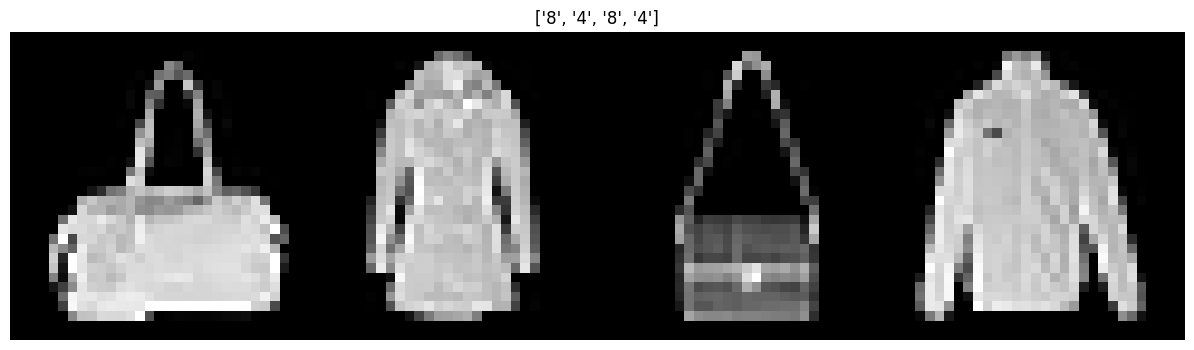

In [8]:
images, labels= show_batch_images(trainloader)

classes = {
0: "T-Shirt/Top",
1: "Trouser",
2: "Pullover",
3: "Dress",
4: "Coat",
5:
덩andal" ,
6: "Shirt",
7: "Sneaker",
8: "Bag" ,
9: "Ankle Boot"
}

In [9]:
# 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()
        self.classifier= nn.Sequential(
            nn.Linear(784, 48),
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Linear(24, 10)
        )

    def forward(self, x):
        x= x.view(x.size(0), -1)
        # 위에서 정의한 계층 호출
        x= self.classifier(x)
        return x

In [10]:
# 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()
        self.classifier= nn.Sequential(
            nn.Linear(784, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Linear(24, 10)
        )

    def forward(self, x):
        x= x.view(x.size(0), -1)
        x= self.classifier(x)
        return x

- BatchNorm1d 로 입력분포 고르게 맞춰줌

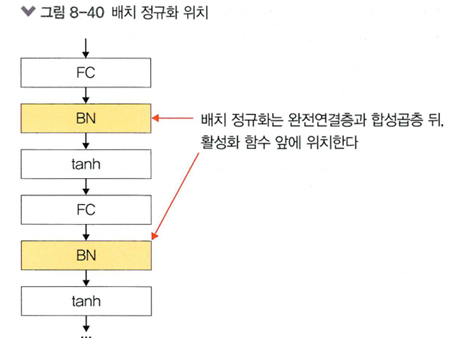

In [11]:
# 배치 정규화가 적용되지 않은 모델 선언
model= NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [12]:
# 배치정규화 적용된 모델 선언
model_bn= BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [13]:
# 데이터셋 메모리로 불러오기 (학습위한 용도)
batch_size= 512
trainloader= torch.utils.data.DataLoader(trainset, batch_size= batch_size, shuffle= True)

In [14]:
# 옵티마이저, 손실함수 지정
loss_fn= nn.CrossEntropyLoss()
opt= optim.SGD(model.parameters(), lr=0.01)
opt_bn= optim.SGD(model_bn.parameters(), lr=0.01)

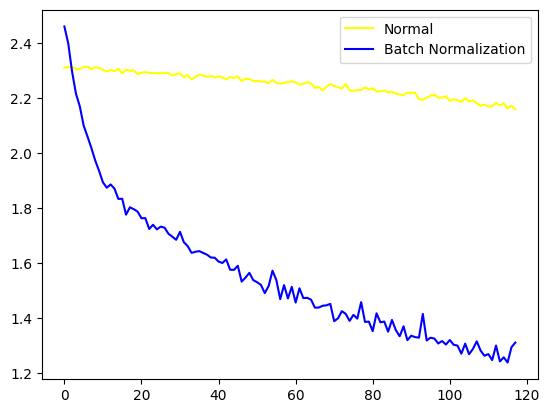

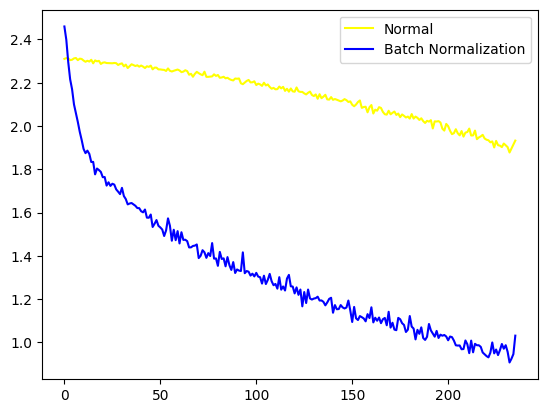

In [15]:
# 모델 학습
loss_arr=[]
loss_bn_arr=[]
max_epochs=2

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels= data
        # 배치 정규화 적용안된 모델
        opt.zero_grad()
        outputs= model(inputs)
        loss= loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        opt_bn.zero_grad()
        outputs_bn= model_bn(inputs)
        loss_bn= loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

    plt.plot(loss_arr, 'yellow', label= 'Normal')
    plt.plot(loss_bn_arr, 'blue', label= 'Batch Normalization')
    plt.legend()
    plt.show()


- 오차 정보 보여줌
- 배치정규화 적용된 모델(파란색)과 적용안된 모델(노란색)
- 배치정규화 적용 모델이 더 낮은, 안정적인 범위 내에서 줄어듬

In [16]:
# 드롭아웃 살펴보기
# 데이터셋의 분포를 출력하기 위한 전처리
N=50
noise= 0.3

x_train= torch.unsqueeze(torch.linspace(-1,1,N),1)
y_train= x_train+ noise*torch.normal(torch.zeros(N,1), torch.ones(N,1))

x_test= torch.unsqueeze(torch.linspace(-1,1,N),1)
y_test= x_test+ noise*torch.normal(torch.zeros(N,1), torch.ones(N,1))

- torch.unsqueeze : 차원 증가
  - torch.linspace() 텐서의 첫번째 차원 증가 시키는 코드
  -  torch.unsqueeze(torch.linspace(-1 , 1, N) , 1)

- torch.normal : 훈련데이터셋 범위가 정규분포 갖도록 함


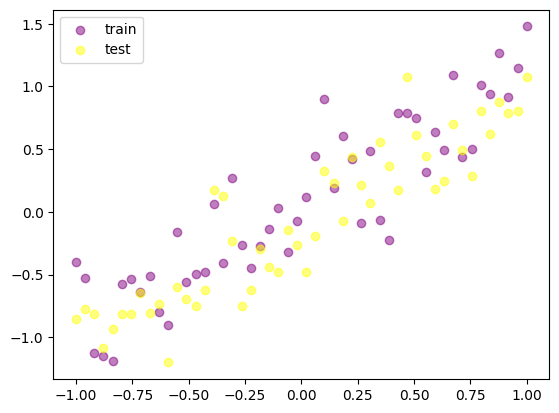

In [17]:
# 데이터 분포를 그래프로 출력
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple', alpha=0.5, label='train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow', alpha=0.5, label='test')
plt.legend()
plt.show()

- c= 그래프로 출력되는 마커의 그래프 중 작은 동그라미, 점

In [18]:
# 드롭아웃을 위한 모델 생성
N_h= 100

model= torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1)
)

model_dropout= torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(p=0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(p=0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,1)
)

In [19]:
# 옵티마이저와 손실 함수
opt= torch.optim.Adam(model.parameters(), lr= 0.01)
opt_dropout= torch.optim.Adam(model_dropout.parameters(), lr= 0.01)
loss_fn= torch.nn.MSELoss()

/tmp/ipykernel_38936/959730931.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title(' Epoch %d, Loss =%0.4f, Loss with dropout= %0.4f'%(epoch, test_loss, test_loss_dropout) )


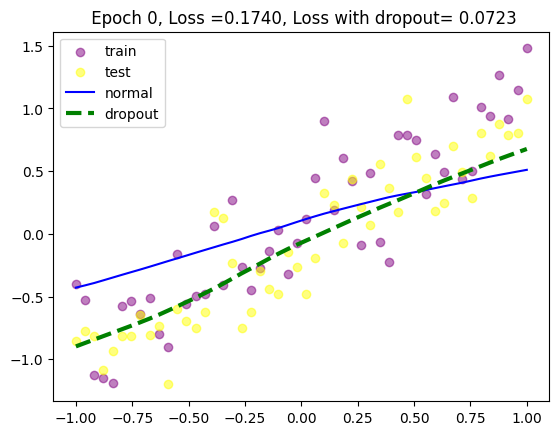

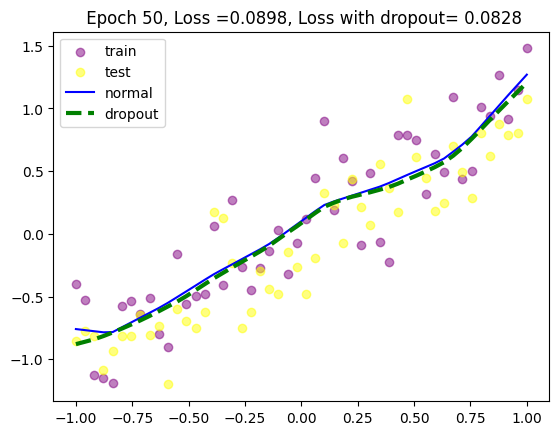

In [20]:
# 모델 학습
max_epochs=100
for epoch in range(max_epochs):
    pred= model(x_train)
    loss= loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    pred_dropout= model_dropout(x_train)
    loss_dropout= loss_fn(pred_dropout, y_train)
    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    if epoch%50 ==0:
        model.eval()
        model_dropout.eval()

        test_pred=model(x_test)
        test_loss= loss_fn(test_pred, y_test)

        test_pred_dropout= model_dropout(x_test)
        test_loss_dropout= loss_fn(test_pred_dropout, y_test)

        plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple', alpha=0.5, label='train')
        plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow', alpha=0.5, label='test')

        plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', label= 'normal')
        plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3, label= 'dropout')

        plt.title(' Epoch %d, Loss =%0.4f, Loss with dropout= %0.4f'%(epoch, test_loss, test_loss_dropout) )

        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)

- 드롭아웃 적용(초록색) 했을때 오차 낮음
- 훈련 횟수 늘어날수록 드롭아웃 적용안한(파란색) 것은 자주색 점을 찾아감 -> 과적합

**8.3.3 조기 종료를 이용한 성능 최적화**
- 조기 종료: 뉴럴 네트워크가 과적합을 회피하는 규제 기법
  - 매 에포크마다 검증 데이터에 대한 오차를 측정하여 모델 종료 시점 제어
  - 과적합 발생 시 검증 데이터셋 오차 증가함 -> 학습 멈춰

++ 학습률 조정해서 성능 향상시키는 것도 확인

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

# 사전 학습 모델 사용 라이브러리
import torchvision.models as models
from torchvision import transforms, datasets
import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm

# 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 함
matplotlib.style.use('ggplot')
device = torch.device( "cuda:0" if torch.cuda.is_available() else "cpu" )

In [22]:
# 데이터셋 전처리
train_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [23]:
# 데이터셋 가져오기
train_dataset= datasets.ImageFolder(
    root=r'/content/drive/MyDrive/ESSA/OB/hotdog dataset/train',
    transform= train_transform
)

train_dataloader= torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True,
)

val_dataset= datasets.ImageFolder(
    root= r'/content/drive/MyDrive/ESSA/OB/hotdog dataset/test',
    transform= val_transform
)
val_dataloader= torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False,
)

- 모델 생성 시 네트워크 직접 구축하지 않고 사전 학습된 ResNet50 사용할 것

In [24]:
# 모델 생성
def resnet50(pretrained=True, requires_grad=True):
    model= models.resnet50(progress=True, pretrained=pretrained)

    # 파라미터 고정하여 역전파 중에 기울기 계산되지 않도록 함
    if requires_grad==False:
        for param in model.parameters():
            param.requires_grad=False

    elif requires_grad==True:
        for param in model.parameters():
            param.requires_grad=True

    model.fc= nn.Linear(2048, 2)
    return model

- 성능 튜닝 기법 -> 학습률 감소
> learning rate scheduler : 주어진 patience 횟수만큼 검증 데이터셋에 대한 오차 감소가 없으면, 주어진 factor만큼 학습률 감소시킴

In [25]:
# 학습률 감소
class LRScheduler():
    def __init__(
            self, optimizer, patience=5, min_lr= 1e-6, factor= 0.5
    ):

        self.optimizer= optimizer
        self.patience= patience
        self.min_lr= min_lr
        self.factor= factor

        # 학습 시 모델 성능 개선 없을 경우 학습률 값 조절하는 콜백 함수
        self.lr_scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=self.patience,
            factor=self.factor,
            min_lr=self.min_lr,
            verbose=True
        )

    # 실제로 학습률 업데이트
    # -> 검증 데이터셋에 대한 오차를 이전과 비교해서 차이없으면 학습률 업데이트
    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)






```
torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=self.patience,
            factor=self.factor,
            min_lr=self.min_lr,
            verbose=True
)
```
- lr_scheduler.ReduceLROnPlateau : 검증 데이터셋에 대해 오차변동 없으면 학습률을 factor배 감소
- mode : 언제 학습률 조정할지에 대한 기준이 되는 값
  - 기준이 정확도이면 max, 오차이면 min으로 지정
- patience : 학습률 업데이트 전 기다릴 에포크 수
- factor : 감소시킬 학습률 크기 -> 기존 학습률*factor = 새 학습률
- min_lr : 학습률 하한선 지정 -> 새 학습률에 곱해서 하한선값 정함
- verbose : 조기 종료의 시작과 끝 출력, 1-> 조기 종료가 적용되었음을 알려줌

In [26]:
# 조기 종료
class EarlyStopping():
    def __init__(self, patience=5, verbose=False, delta=0,
                 path='/content/checkpoint.pt'):
        self.patience= patience
        self.verbose= verbose
        self.counter=0

        # 최고점수의 초기값을 None으로 -> 추후에 오차 최적화 값으로 업데이트
        self.best_score=None
        # 조기종료 여부의미 -> 초기에는 조기 종료 안함
        self.early_stop= False
        self.val_loss_min= np.Inf
        self.delta= delta
        self.path= path

    # best_loss에 진전이 없으면 조기 종료 후 모델 저장
    def __call__(self, val_loss, model):
        score= -val_loss
        if self.best_score is None:
            self.best_score= score
            self.save_checkpoint(val_loss, model)

        elif score< self.best_score + self.delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter>= self.patience:
                self.early_stop= True
        else:
            self.best_score= score
            self.save_checkpoint(val_loss, model)
            self.counter=0

    # 검증 데이터셋에 대한 오차 감소 시 모델 저장
    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f}--> {val_loss:.6f}). Saving model...')

        torch.save(model.state_dict(), self.path)
        self.val_loss_min= val_loss


- patience : 개선 없는 에포크 기다려줄 횟수
- delta : 오차 개선이라고 판단하는 최소 변화량

-> 케라스 콜백 사용하면 쉬움
```
from keras.ca11backs import Mode1Checkpoint, Ear1yStopping

checkpoint = Mode1Checkpoint( ’ checkpoint-epoch.h5' .format(EPOCH, BATCH_SIZE) , ‘
monitor= ’ va1 10ss ’ , ------ val_loss 값이 개선되었을 때 호출

verbose=1. ------ 로그 출력

save_best_on1y=True, ------ 가장 최적의 값만 저장

mode= ’ auto ’ ------auto 의미는 시스템이 알아서 best 값을 찾으라는 것

ear1ystopping = Ear1yStopping(monitor= ’ va1_10ss ’ ------학습률 업데이트 기준 설정(val_loss)

patience=10 ------ 에포크가 진행되는 열 번 동안 모델의 오차가 개선되지 않으면 종료
)
```

- 학습률 감소, 조기 종료 두개 성능 튜닝 진행하고 있음 -> argparse 라이브러리로 함수에 넘겨주는 인수값에 따라 다른 동작 하도록
  - ArgumentParser() 로 변수, 타입 지정
  - add_argument() 로 변수에 인수 값 추가
  - parse_args() 로 사용자에게 입력받은 값들을 args 변수에 저장


In [27]:
# 인수 값 지정
parser= argparse.ArgumentParser() # 인수 값을 받을 수 있는 인스턴스 생성

#1
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')

parser.add_argument('--early-stopping', dest='early_stopping', action='store_true')

#2
args, unknown = parser.parse_known_args()
args = vars(args)

1. 기능 목적

파이썬 프로그램을 터미널(명령 프롬프트)에서 실행할 때, 매번 코드를 수정하지 않고 외부에서 스위치를 켜고 끄듯 특정 기능(lr-scheduler, early-stopping 등)을 제어하기 위함.

2. 코드 및 라인별 역할

parser = argparse.ArgumentParser()

📥 터미널 입력 접수처 생성: 인수 값을 받아들이고 처리할 수 있는 기본 인스턴스를 만듦.

parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')

1️⃣ '--lr-scheduler': 터미널에서 입력할 스위치 이름 (대시 -- 필수)

2️⃣ dest='lr_scheduler': 스위치 결과가 저장될 프로그램 내 변수 이름

3️⃣ action='store_true': 별도 값(True/False) 입력 없이, 이름만 적으면 자동으로 True 저장 (안 적으면 False)

args = vars(parser.parse_args())

🗂️ 딕셔너리 변환: 입력받은 스위치 결과들을 파이썬에서 쓰기 편하게 {'변수명': 값} 형태(Dictionary)로 묶어서 args에 저장.

💻 터미널 실행에 따른 args 결과 값 비교

케이스 A: 기능을 모두 켜고 싶을 때

명령어: python main.py --lr-scheduler --early-stopping

args 결과: {'lr_scheduler': True, 'early_stopping': True}

케이스 B: 기능을 모두 끄고 싶을 때

명령어: python main.py

args 결과: {'lr_scheduler': False, 'early_stopping': False}

In [28]:
# 사전 훈련된 모델의 파라미터 확인
print(f'Computation device: {device}\n')
model= models.resnet50(pretrained=True).to(device)

# 총 파라미터 수
total_params= sum(p.numel() for p in model.parameters())
print(f'{total_params:,} total parameters')

total_trainable_params= sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters')

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


25,557,032 total parameters
25,557,032 training parameters


In [29]:
# 옵티마이저와 손실함수 지정
lr= 0.001
epochs= 100
optimizer= optim.Adam(model.parameters(), lr=lr)
criterion= nn.CrossEntropyLoss()

- 어떤 인수도 사용하지 않을때 사용할 문자열 지정

In [30]:
# 오차, 정확도 및 모델의 이름에 대한 문자열
loss_plot_name= 'loss'
acc_plot_name='accuracy'
model_name='model'

- 인수 사용할 경우 사용할 문자열 지정

In [31]:
# 오차, 정확도 및 모델의 이름에 대한 문자열
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')
    lr_scheduler= LRScheduler(optimizer)
    loss_plot_name= 'loss_scheduler'
    acc_plot_name='accuracy_scheduler'
    model_name='model_scheduler'
if args['early_stopping']:
    print('INFO: Initializing early stopping')
    early_stopping= EarlyStopping()
    loss_plot_name= 'es_loss'
    acc_plot_name='es_accuracy'
    model_name='es_model'

In [32]:
# 모델 학습 함수
def training(model, train_dataloader, train_dataset, optimizer, criterion):
    print('Training')
    model.train()
    train_running_loss=0.0
    train_running_correct=0
    counter=0
    total=0

    # 훈련 진행과정을 시각적으로 표현
    prog_bar= tqdm(enumerate(train_dataloader), total= int(len(train_dataset)/
                                                           train_dataloader.batch_size))

    for i, data in prog_bar:
        counter +=1
        data, target= data[0].to(device), data[1].to(device)
        total+= target.size(0)
        optimizer.zero_grad()
        outputs= model(data)
        loss= criterion(outputs, target)
        train_running_loss += loss.item()
        _, preds= torch.max(outputs.data, 1)
        train_running_correct += (preds==target).sum().item()
        loss.backward()
        optimizer.step()

    train_loss= train_running_loss/ counter
    train_accuracy= 100. * (train_running_correct/total)
    return train_loss, train_accuracy


In [33]:
# 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()
    val_running_loss=0.0
    val_running_correct=0
    counter=0
    total=0

    # 모델 검증과정을 시각적으로 표현
    prog_bar= tqdm(enumerate(train_dataloader), total= int(len(train_dataset)/
                                                           train_dataloader.batch_size))
    with torch.no_grad():
        for i, data in prog_bar:
            counter +=1
            data, target= data[0].to(device), data[1].to(device)
            total+= target.size(0)
            outputs= model(data)
            loss= criterion(outputs, target)

            val_running_loss += loss.item()
            _, preds= torch.max(outputs.data, 1)
            val_running_correct += (preds==target).sum().item()


        val_loss= val_running_loss/ counter
        val_accuracy= 100. * (val_running_correct/total)
        return val_loss, val_accuracy


In [34]:
# 모델 학습

train_loss, train_accuracy= [], []
val_loss, val_accuracy= [], []

start= time.time()
for epoch in range(epochs):
    print(f'Epoch {epoch+1} of {epochs}')
    train_epoch_loss, train_epoch_accuracy= training(model, train_dataloader, train_dataset, optimizer, criterion)
    val_epoch_loss, val_epoch_accuracy= validate(model, val_dataloader, val_dataset, criterion)
    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)
    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)

    if args['lr_scheduler']:
        lr_scheduler(val_epoch_loss)

    if args['early_stopping']:
        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            break

    print(f'Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}')
    print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}')
end=time.time()
print(f'Training time: {(end-start)/ 60:.3f} minutes')

Epoch 1 of 100
Training


16it [01:38,  6.19s/it]


Validating


16it [00:05,  3.00it/s]


Train Loss: 2.2417, Train Acc: 58.63
Val Loss: 6.9279, Val Acc: 44.58
Epoch 2 of 100
Training


...

Train Loss: 0.1093, Train Acc: 95.58
Val Loss: 0.1438, Val Acc: 94.58
Epoch 100 of 100
Training


16it [00:06,  2.63it/s]


Validating


16it [00:04,  3.24it/s]

Train Loss: 0.0908, Train Acc: 96.39
Val Loss: 0.1691, Val Acc: 94.58
Training time: 20.972 minutes


Saving loss and accuracy plots...


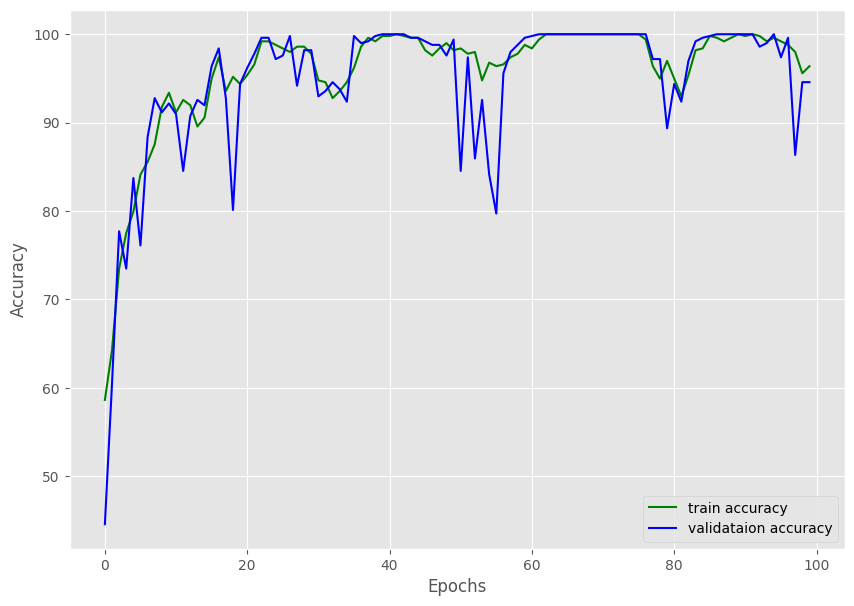

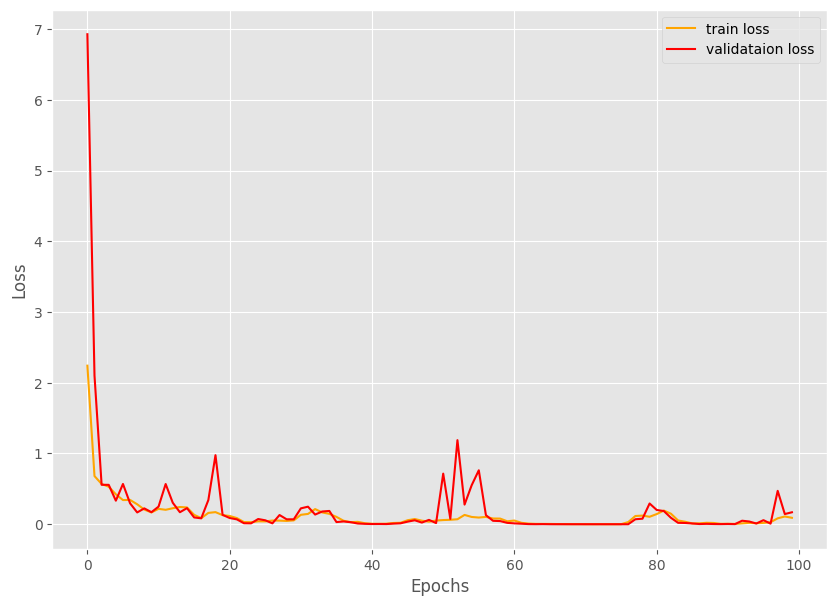

Saving model...
TRANING COMPLETE


In [35]:
# 모델 학습 결과 출력
# 어떤 인수도 사용되지 않는 모델의 학습결과
print('Saving loss and accuracy plots...')

plt.figure(figsize=(10,7))
plt.plot(train_accuracy, color='green', label='train accuracy')
plt.plot(val_accuracy, color='blue', label='validataion accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'/content/drive/MyDrive/ESSA/OB/{loss_plot_name}.png')
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train loss')
plt.plot(val_loss, color='red', label='validataion loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'/content/drive/MyDrive/ESSA/OB/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'/content/drive/MyDrive/ESSA/OB/{model_name}.pth')
print('TRANING COMPLETE')

최종
- 그래프의 의미를 잘 이해하고 조기종료를 사용하는것이 좋다.
- 학습률 스케줄러를 이용한 학습률 조정기법과 조기종료가 모델성능을 향상시키는데에 도움이 된다.